# USD SOFR Curve Bootstrapping & 20Y Swap NPV — Multiple Valuation Dates

This notebook bootstraps USD SOFR discount factor curves (simplified, reference-style) from Bloomberg-exported swap par rates,
and prices a **20Y pay-fixed 4.50%** SOFR swap on each valuation date:
- 2024-12-31
- 2025-03-31
- 2025-06-30
- 2025-09-30
- 2025-12-31

It also plots the curves for comparison.

> **Simplifying assumptions**
> - No calendars / business-day adjustments  
> - ACT/360 accrual  
> - Annual fixed payments (Freq=1 from Bloomberg export)  
> - Floating leg cashflows are generated using **simple forwards implied by discount factors**

In [3]:
import math
import datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dateutil.relativedelta import relativedelta

## 1) File map 

In [5]:
FILES = {
    dt.date(2024,12,31): "All Swap Rates_31December24.xlsx",
    dt.date(2025,3,31):  "All swaps_31March25.xlsx",
    dt.date(2025,6,30):  "All Swaps_30june25.xlsx",
    dt.date(2025,9,30):  "All swaps_30september25.xlsx",
    dt.date(2025,12,31): "All swaps_31December25.xlsx",
}

## 2) load swap par rates 

In [7]:
def read_swap_sheet(path: str) -> pd.DataFrame:
    xls = pd.ExcelFile(path)
    sheet = "Worksheet" if "Worksheet" in xls.sheet_names else xls.sheet_names[0]
    return pd.read_excel(path, sheet_name=sheet, header=0)

def load_bbg_swap_rates(path: str) -> pd.DataFrame:
    df = read_swap_sheet(path)
    df = df.rename(columns={c: str(c).strip() for c in df.columns})

    if "Rate Type" in df.columns:
        df = df[df["Rate Type"].astype(str).str.strip().eq("Swap Rates")].copy()

    bid_col = "Final Bid Rate" if "Final Bid Rate" in df.columns else ("Bid" if "Bid" in df.columns else None)
    ask_col = "Final Ask Rate" if "Final Ask Rate" in df.columns else ("Ask" if "Ask" in df.columns else None)
    if bid_col is None or ask_col is None:
        raise ValueError(f"Missing bid/ask columns in {path}.")

    df["mid_rate_pct"] = (pd.to_numeric(df[bid_col], errors="coerce") + pd.to_numeric(df[ask_col], errors="coerce"))/2.0
    df = df.dropna(subset=["Term","Unit","mid_rate_pct"]).copy()

    df["Term"] = pd.to_numeric(df["Term"], errors="coerce")
    df = df.dropna(subset=["Term"]).copy()
    df["Term"] = df["Term"].astype(int)

    if "Ticker" not in df.columns:
        df["Ticker"] = df.index.astype(str)

    return df[["Term","Unit","Ticker","mid_rate_pct"]].reset_index(drop=True)

## 3) Bootstrapping discount factors from annual-pay swap par rates

In [9]:
def add_tenor(start: dt.date, term: int, unit: str) -> dt.date:
    unit = str(unit).upper().strip()
    if unit in ("WK","W","WKS","WEEK","WEEKS"):
        return start + dt.timedelta(days=7*int(term))
    if unit in ("MO","M","MOS","MONTH","MONTHS"):
        return start + relativedelta(months=int(term))
    if unit in ("YR","Y","YRS","YEAR","YEARS"):
        return start + relativedelta(years=int(term))
    raise ValueError(f"Unknown unit: {unit}")

def yearfrac_act360(d0: dt.date, d1: dt.date) -> float:
    return (d1 - d0).days / 360.0

def fixed_pay_dates_annual(start: dt.date, end: dt.date):
    dates = []
    cur = start + relativedelta(years=1)
    while cur < end:
        dates.append(cur)
        cur = cur + relativedelta(years=1)
    dates.append(end)
    return dates

class DiscountCurve:
    def __init__(self, val_date: dt.date):
        self.val_date = val_date
        self.nodes = {val_date: 1.0}

    def add(self, date: dt.date, df: float):
        self.nodes[date] = float(df)

    def df(self, date: dt.date) -> float:
        if date in self.nodes:
            return self.nodes[date]
        dates = sorted(self.nodes.keys())
        if date <= dates[0]:
            return self.nodes[dates[0]]
        if date >= dates[-1]:
            return self.nodes[dates[-1]]

        for i in range(1, len(dates)):
            if dates[i] > date:
                dL, dR = dates[i-1], dates[i]
                break

        # log-linear DF interpolation
        tL = (dL - self.val_date).days / 365.0
        tR = (dR - self.val_date).days / 365.0
        t  = (date - self.val_date).days / 365.0
        w = (t - tL) / (tR - tL)
        ln_df = (1-w)*math.log(self.nodes[dL]) + w*math.log(self.nodes[dR])
        return math.exp(ln_df)

    def node_table(self) -> pd.DataFrame:
        return pd.DataFrame([{"date": d, "df": self.nodes[d]} for d in sorted(self.nodes.keys())])

def bootstrap_from_swaps(swap_data: pd.DataFrame, val_date: dt.date, max_years: int = 20):
    curve = DiscountCurve(val_date)
    rows = []

    cutoff = val_date + relativedelta(years=max_years)

    data = swap_data.copy()
    data["maturity"] = data.apply(lambda r: add_tenor(val_date, int(r["Term"]), r["Unit"]), axis=1)
    data = data[data["maturity"] <= cutoff].sort_values("maturity").reset_index(drop=True)

    for _, r in data.iterrows():
        end  = r["maturity"]
        rate = float(r["mid_rate_pct"]) / 100.0

        pay_dates = fixed_pay_dates_annual(val_date, end)

        # A = sum_{i=1..N-1} DF(t_i)*tau_i
        A = 0.0
        prev = val_date
        for d in pay_dates[:-1]:
            tau = yearfrac_act360(prev, d)
            A += tau * curve.df(d)
            prev = d

        tauN = yearfrac_act360(prev, pay_dates[-1])
        dfN  = (1.0 - rate*A) / (1.0 + rate*tauN)

        curve.add(pay_dates[-1], dfN)

        rows.append({
            "instrument": r["Ticker"],
            "tenor": f'{int(r["Term"])}{str(r["Unit"]).upper()}',
            "maturity": end,
            "par_rate_pct": float(r["mid_rate_pct"]),
            "df(maturity)": dfN
        })

    return curve, pd.DataFrame(rows)

## 4) 20Y pay-fixed 4.50% swap pricing (cashflows + NPV)

In [11]:
def price_pay_fixed_swap(curve: DiscountCurve,
                         start: dt.date,
                         end: dt.date,
                         fixed_rate: float,
                         notional: float = 1.0):
    pay_dates = fixed_pay_dates_annual(start, end)

    rows = []
    pv_fixed = 0.0
    pv_float = 0.0

    prev = start
    for d in pay_dates:
        tau = yearfrac_act360(prev, d)

        df_prev = curve.df(prev)
        df_d    = curve.df(d)

        fwd = (df_prev/df_d - 1.0) / tau  # simple forward

        fixed_cf = notional * fixed_rate * tau
        float_cf = notional * fwd * tau

        pvF = fixed_cf * df_d
        pvL = float_cf * df_d

        pv_fixed += pvF
        pv_float += pvL

        rows.append({
            "period_start": prev,
            "pay_date": d,
            "tau_act360": tau,
            "df(pay_date)": df_d,
            "fwd_simple": fwd,
            "fixed_cf": fixed_cf,
            "float_cf": float_cf,
            "pv_fixed": pvF,
            "pv_float": pvL,
            "net_pv (float-fixed)": pvL - pvF
        })
        prev = d

    cf = pd.DataFrame(rows)
    npv = pv_float - pv_fixed
    return cf, pv_fixed, pv_float, npv

## 5) Run all dates: bootstrap curve → compute swap NPV

In [13]:
FIXED_RATE = 0.045
MAX_YEARS  = 20

curves = {}
inst_tables = {}
cashflows = {}
summary_rows = []

for vd, path in FILES.items():
    swaps = load_bbg_swap_rates(path)
    curve, inst = bootstrap_from_swaps(swaps, vd, max_years=MAX_YEARS)

    end = vd + relativedelta(years=MAX_YEARS)
    cf, pvF, pvL, npv = price_pay_fixed_swap(curve, vd, end, FIXED_RATE, notional=1.0)

    curves[vd] = curve
    inst_tables[vd] = inst
    cashflows[vd] = cf

    summary_rows.append({
        "val_date": vd,
        "DF(20Y)": curve.df(end),
        "pv_fixed": pvF,
        "pv_float": pvL,
        "NPV (1 notional)": npv
    })

summary = pd.DataFrame(summary_rows).sort_values("val_date").reset_index(drop=True)
summary

,val_date,DF(20Y),pv_fixed,pv_float,NPV (1 notional)
0,2024-12-31,0.434803,0.610370,0.565197,-0.045173
1,2025-03-31,0.450088,0.625208,0.549912,-0.075297
2,2025-06-30,0.440254,0.626002,0.559746,-0.066256
3,2025-09-30,0.438056,0.626608,0.561944,-0.064664
4,2025-12-31,0.417602,0.617185,0.582398,-0.034788


### Discount factors at each instrument maturity (per date)

In [15]:
# Example: instrument DF table for 2024-12-31
inst_tables[dt.date(2024,12,31)]

,instrument,tenor,maturity,par_rate_pct,df(maturity)
0,USOSFR1Z,1WK,2025-01-07,4.327500,0.999159
1,USOSFR2Z,2WK,2025-01-14,4.324500,0.998321
2,USOSFR3Z,3WK,2025-01-21,4.325500,0.997483
3,USOSFRA,1MO,2025-01-31,4.323150,0.996291
4,USOSFRB,2MO,2025-02-28,4.318000,0.992973
5,USOSFRC,3MO,2025-03-31,4.302000,0.989359
6,USOSFRD,4MO,2025-04-30,4.281760,0.985928
7,USOSFRE,5MO,2025-05-31,4.264000,0.982429
8,USOSFRF,6MO,2025-06-30,4.249500,0.979081
9,USOSFRG,7MO,2025-07-31,4.232790,0.975680


### Swap cashflows (per date)

In [17]:
# Example: cashflows for 2024-12-31
cashflows[dt.date(2024,12,31)]

,period_start,pay_date,tau_act360,df(pay_date),fwd_simple,fixed_cf,float_cf,pv_fixed,pv_float,net_pv (float-fixed)
0,2024-12-31,2025-12-31,1.013889,0.959381,0.041759,0.045625,0.042339,0.043772,0.040619,-0.003153
1,2025-12-31,2026-12-31,1.013889,0.922211,0.039754,0.045625,0.040306,0.042076,0.037170,-0.004905
2,2026-12-31,2027-12-31,1.013889,0.886219,0.040056,0.045625,0.040612,0.040434,0.035992,-0.004442
3,2027-12-31,2028-12-31,1.016667,0.851594,0.039992,0.045750,0.040659,0.038960,0.034625,-0.004336
4,2028-12-31,2029-12-31,1.013889,0.818203,0.040252,0.045625,0.040811,0.037330,0.033392,-0.003939
5,2029-12-31,2030-12-31,1.013889,0.785764,0.040718,0.045625,0.041283,0.035850,0.032439,-0.003412
6,2030-12-31,2031-12-31,1.013889,0.754496,0.040875,0.045625,0.041443,0.034424,0.031268,-0.003156
7,2031-12-31,2032-12-31,1.016667,0.724253,0.041073,0.045750,0.041757,0.033135,0.030243,-0.002892
8,2032-12-31,2033-12-31,1.013889,0.695142,0.041303,0.045625,0.041877,0.031716,0.029110,-0.002606
9,2033-12-31,2034-12-31,1.013889,0.666967,0.041665,0.045625,0.042244,0.030430,0.028175,-0.002255


## 6) Plot the curves

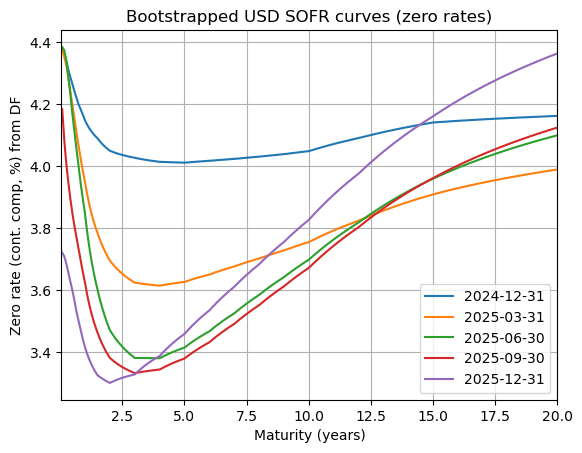

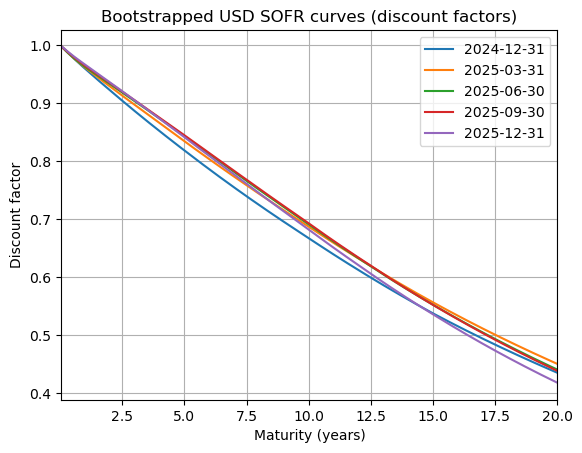

In [19]:
def curve_points_for_plot(curve: DiscountCurve, val_date: dt.date, max_years=20):
    end = val_date + relativedelta(years=max_years)
    dates = [val_date + relativedelta(months=m) for m in range(0, max_years*12 + 1)]
    dates = [d for d in dates if d <= end]
    t = np.array([(d - val_date).days/365.0 for d in dates])
    df = np.array([curve.df(d) for d in dates])
    z = np.array([0.0 if ti == 0 else -math.log(dfi)/ti for dfi, ti in zip(df, t)])
    return t, df, z

# Zero-rate curves
plt.figure()
for vd in sorted(curves.keys()):
    t, df, z = curve_points_for_plot(curves[vd], vd, MAX_YEARS)
    mask = t > 1e-6
    plt.plot(t[mask], (z[mask]*100), label=str(vd))
plt.xlabel("Maturity (years)")
plt.xlim(0.05, MAX_YEARS)
plt.ylabel("Zero rate (cont. comp, %) from DF")
plt.title("Bootstrapped USD SOFR curves (zero rates)")
plt.grid(True)
plt.legend()
plt.show()

# Discount factor curves
plt.figure()
for vd in sorted(curves.keys()):
    t, df, z = curve_points_for_plot(curves[vd], vd, MAX_YEARS)
    mask = t > 1e-6
    plt.plot(t[mask], df[mask], label=str(vd))
plt.xlabel("Maturity (years)")
plt.xlim(0.05, MAX_YEARS)
plt.ylabel("Discount factor")
plt.title("Bootstrapped USD SOFR curves (discount factors)")
plt.grid(True)
plt.legend()
plt.show()